In [3]:
# Core Python libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import random

# TensorFlow / Keras essentials
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications, callbacks, optimizers
from tensorflow.keras.preprocessing import image_dataset_from_directory

# For class weight calculation
from sklearn.utils import class_weight

# For mounting Google Drive
from google.colab import drive

# Check version (optional but good practice)
print("TensorFlow version:", tf.__version__)
print("GPU Available:", "Yes" if tf.config.list_physical_devices('GPU') else "No")

TensorFlow version: 2.20.0
GPU Available: Yes


In [4]:
# Mount your Google Drive to access the dataset
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# List everything inside your main Google Drive folder
base_path = '/content/drive/MyDrive/'
print("Files and folders in your MyDrive:")
for item in os.listdir(base_path):
    print(f" - {item}")

# Set the correct path to your dataset.
# This is already correct for your folder!
dataset_path = base_path + 'Dog_Skin_Disease_Final_Dataset'

# Verify the path exists and check the subfolders (which are your classes)
if os.path.exists(dataset_path):
    print(f"\n✅ Dataset found at: {dataset_path}")
    print("Subfolders (your image classes):", os.listdir(dataset_path))
else:
    print(f"\n❌ Folder not found at {dataset_path}. Please copy the correct path from the list above.")

Files and folders in your MyDrive:
 - Classroom
 - Dv anisa
 - naxal menu.docx
 - IMG_1503.mov
 - copy_95482326-687A-4069-A3CC-FB712C62B83F.mov
 - IMG_3242.HEIC
 - Imgs
 - Rksi
 - Birthday 
 - Adhikari (Prabin) 800820290 I20.pdf
 - UHP Application2023.pdf
 - Saved from Chrome
 - File_000
 - thrilling-and-tense-sound-effect-01-194450.mp3
 - Sounds
 - Copy of Infraction-Music-For-A-Moment-pr.mp3
 - Untitled folder (1)
 - Untitled document.gdoc
 - Database Management Lab Exercise.docx
 - Untitled folder
 - I2404542            Samiksha GURUNG - sign form copy.pdf
 - I2404542            Samiksha GURUNG - sign form (1).pdf
 - I2404542            Samiksha GURUNG - sign form.pdf
 - I2404542            Samiksha GURUNG - sign form.gdoc
 - Videos
 - oscar winners
 - Colab Notebooks
 - computer network rubiks.gdoc
 - nepal_seismicity_master.gsheet
 - PacketTracer_StepByStep_Guide.docx
 - dataset
 - NepaliFoodClassification
 - Dog_Skin_Disease_Final_Dataset

✅ Dataset found at: /content/drive/MyDri

In [6]:
# Data augmentation pipeline
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# This will be inserted at the beginning of the EfficientNet model later.

In [7]:
# Load the dataset from train/ and valid/ folders
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications, callbacks, optimizers

train_dir = '/content/drive/MyDrive/Dog_Skin_Disease_Final_Dataset/train'
valid_dir = '/content/drive/MyDrive/Dog_Skin_Disease_Final_Dataset/valid'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)   # <-- This is what you need

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")

Found 247 files belonging to 6 classes.
Found 839 files belonging to 6 classes.
Classes: ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']
Number of classes: 6


In [8]:
def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')  # num_classes is now defined
    ])
    return model

cnn_model = build_cnn()
cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# ---------- Data Augmentation (already defined) ----------
# If you haven't defined it yet:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# ---------- Build EfficientNet-B0 model ----------
def build_efficientnet():
    # Load pre-trained base (without top classification layer)
    base = applications.EfficientNetB0(weights='imagenet',
                                       include_top=False,
                                       input_shape=(224, 224, 3))
    # Stage 1: freeze base
    base.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    # Apply data augmentation (only during training, Keras handles this)
    x = data_augmentation(inputs)
    # Pass through the frozen base
    x = base(x, training=False)   # training=False ensures BatchNorm layers stay in inference mode
    # Custom classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    return model

# Build and compile
eff_model = build_efficientnet()
eff_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │         7,686 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,057,257 (15.48 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [10]:
from sklearn.utils import class_weight
import numpy as np

# Extract all training labels
y_train = np.concatenate([y for x, y in train_ds], axis=0)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(weights))
print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(1.0)}


In [11]:
callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7
    ),
    callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [12]:
# ---------- Hyperparameter Definitions ----------
IMG_SIZE = (224, 224)      # Input resolution
BATCH_SIZE = 32            # Batch size
LEARNING_RATE_STAGE1 = 1e-3   # Default for Adam
LEARNING_RATE_STAGE2 = 1e-5   # Low rate for fine-tuning
NUM_EPOCHS_STAGE1 = 50
NUM_EPOCHS_STAGE2 = 30

# Data loading applies IMG_SIZE and BATCH_SIZE
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=123
)

# Model compilation applies optimiser and loss
eff_model.compile(optimizer=optimizers.Adam(learning_rate=LEARNING_RATE_STAGE1),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

Found 377 files belonging to 6 classes.


In [17]:
import tensorflow as tf
# ---------- Compute Class Weights ----------
from sklearn.utils import class_weight
import numpy as np

# To get labels for class weight calculation, we need to iterate over the dataset.
# The original train_ds will be consumed if we iterate directly.
# So, create a temporary dataset for this purpose, and ensure it's not shuffled
# so we can reliably get all labels.
temp_train_ds_for_weights = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE, # Use the same batch size
    shuffle=False, # Important: Don't shuffle for consistent label extraction
    seed=123 # Keep seed consistent for reproducibility, even if shuffle=False
)

# Get all labels from the training set (from the fresh dataset)
y_train = np.concatenate([y_batch for x_batch, y_batch in temp_train_ds_for_weights], axis=0)

# Now compute the class weights
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train), # It's crucial that this contains all expected classes (0 to num_classes-1)
    y=y_train
)
class_weight_dict = dict(enumerate(weights))
print("Class Weights:", class_weight_dict)

# After extracting y_train, the original 'train_ds' (from previous cell `kOZCT780e6NT`)
# might have been consumed or altered. It's best practice to re-create it
# along with val_ds to ensure they are fresh and ready for model training (fit calls).
# This also makes sure that the train_ds for training is shuffled.

# Re-define train_ds and val_ds again for model training
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True, # Shuffle for training
    seed=123
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    valid_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # No need to shuffle validation data
)

# ---------- Define Callbacks ----------
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

# ---------- SAFETY: set epochs to smaller values for testing ----------
# Use these for a quick test; restore to 50 and 30 for the final run.
EPOCHS_PHASE1 = 5      # originally 50
EPOCHS_PHASE2 = 5      # originally 30
EPOCHS_CNN     = 5      # originally 50

# ---------- Phase 1: Feature Extraction ----------
print(">>> PHASE 1: Training with frozen base (quick test)")
history_phase1 = eff_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=my_callbacks,
    class_weight=class_weight_dict
)

# ---------- Phase 2: Fine-Tuning ----------
print(">>> PHASE 2: Fine-tuning with unfrozen base (quick test)")

# Identify the EfficientNetB0 layer by name
base_layer = None
for layer in eff_model.layers:
    if layer.name == 'efficientnetb0':   # default name when using applications.EfficientNetB0
        base_layer = layer
        break

if base_layer is None:
    raise ValueError("EfficientNetB0 layer not found. Check layer names: " + str([layer.name for layer in eff_model.layers]))

# Unfreeze the base
base_layer.trainable = True

# Recompile with a lower learning rate
eff_model.compile(optimizer=optimizers.Adam(learning_rate=1e-5),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# Continue training
history_phase2 = eff_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=my_callbacks,
    class_weight=class_weight_dict
)

# ---------- Baseline CNN Training ----------
print(">>> Training Baseline CNN (quick test)")
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN,
    callbacks=my_callbacks,
    class_weight=class_weight_dict
)

# ---------- Model Selection: Load Best from Checkpoint ----------
best_model = keras.models.load_model('best_model.keras')
val_loss, val_acc = best_model.evaluate(val_ds)
print(f"Best Validation Accuracy: {val_acc:.4f}")

Found 2974 files belonging to 6 classes.
Class Weights: {0: np.float64(0.909480122324159), 1: np.float64(1.420248328557784), 2: np.float64(1.0074525745257452), 3: np.float64(2.3716108452950557), 4: np.float64(0.8429705215419501), 5: np.float64(0.6266329540665824)}
Found 2974 files belonging to 6 classes.
Found 839 files belonging to 6 classes.
>>> PHASE 1: Training with frozen base (quick test)
Epoch 1/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.5777 - loss: 1.2567 - val_accuracy: 0.7282 - val_loss: 0.8282 - learning_rate: 0.0010
Epoch 2/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 20s 213ms/step - accuracy: 0.7488 - loss: 0.8273 - val_accuracy: 0.7998 - val_loss: 0.6479 - learning_rate: 0.0010
Epoch 3/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - accuracy: 0.8056 - loss: 0.6851 - val_accuracy: 0.8260 - val_loss: 0.5722 - learning_rate: 0.0010
Epoch 4/5
93/93 ━━━━━━━━━━━━━━━━━━━━ 18s 190ms/step - accuracy: 0.8201 - loss: 0.6108 - val_accuracy: 0.8403 - val_loss: 0.5173 - learning_rate: 0.0

In [18]:
# ---------- 3.7 Select and Save the Best Model ----------

print("=" * 50)
print("LOADING THE BEST SAVED MODEL FROM CHECKPOINT")
print("=" * 50)

# 1. Load the best model saved by ModelCheckpoint
best_model = keras.models.load_model('best_model.keras')
print("✅ Best model loaded from 'best_model.keras'")

# 2. Final evaluation on the validation set
print("\n>>> Performing final evaluation on validation set...")
val_loss, val_acc = best_model.evaluate(val_ds, verbose=1)
print(f"\n📊 Final Validation Loss:     {val_loss:.4f}")
print(f"📊 Final Validation Accuracy: {val_acc:.4f}")

# 3. Save the final model for deployment (Gradio/Streamlit demo)
best_model.save('final_deployment_model.keras')
print("\n✅ Final deployment model saved as 'final_deployment_model.keras'")

# 4. Save class names in the correct order (for the demo)
import os
with open('class_names.txt', 'w') as f:
    for name in class_names:
        f.write(f"{name}\n")
print("✅ Class names saved to 'class_names.txt'")

# 5. (Optional) Print a performance summary for your report
print("\n" + "=" * 50)
print("📋 MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"Number of Classes: {num_classes}")
print(f"Class Names:       {class_names}")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc * 100:.2f}%)")
print(f"Validation Loss:   {val_loss:.4f}")
print("=" * 50)

# 6. (Optional) Quick test on a few validation images
print("\n>>> Testing on 5 random validation samples...")
sample_images, sample_labels = next(iter(val_ds.take(1)))
predictions = best_model.predict(sample_images[:5])
predicted_classes = np.argmax(predictions, axis=1)

for i in range(5):
    true_label = class_names[sample_labels[i].numpy()]
    pred_label = class_names[predicted_classes[i]]
    confidence = np.max(predictions[i]) * 100
    print(f"Sample {i+1}: True={true_label}, Pred={pred_label}, Confidence={confidence:.1f}%")

LOADING THE BEST SAVED MODEL FROM CHECKPOINT
✅ Best model loaded from 'best_model.keras'

>>> Performing final evaluation on validation set...
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - accuracy: 0.8474 - loss: 0.4809

📊 Final Validation Loss:     0.4809
📊 Final Validation Accuracy: 0.8474

✅ Final deployment model saved as 'final_deployment_model.keras'
✅ Class names saved to 'class_names.txt'

📋 MODEL PERFORMANCE SUMMARY
Number of Classes: 6
Class Names:       ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']
Validation Accuracy: 0.8474 (84.74%)
Validation Loss:   0.4809

>>> Testing on 5 random validation samples...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Sample 1: True=Dermatitis, Pred=Dermatitis, Confidence=95.4%
Sample 2: True=Dermatitis, Pred=Dermatitis, Confidence=85.6%
Sample 3: True=Dermatitis, Pred=Dermatitis, Confidence=70.3%
Sample 4: True=Dermatitis, Pred=Dermatitis, Confidence=93.5%
Sample 5: True=Dermatitis, Pred=Dermatitis, Confi

Evaluate Both Models

In [19]:
print("="*50)
print("CNN MODEL EVALUATION")
print("="*50)

cnn_loss, cnn_acc = cnn_model.evaluate(val_ds, verbose=1)

print(f"CNN Validation Loss : {cnn_loss:.4f}")
print(f"CNN Validation Accuracy : {cnn_acc:.4f}")

print("\n")

print("="*50)
print("EFFICIENTNET-B0 EVALUATION")
print("="*50)

eff_loss, eff_acc = eff_model.evaluate(val_ds, verbose=1)

print(f"EfficientNet Validation Loss : {eff_loss:.4f}")
print(f"EfficientNet Validation Accuracy : {eff_acc:.4f}")

CNN MODEL EVALUATION
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - accuracy: 0.3385 - loss: 1.5642
CNN Validation Loss : 1.5642
CNN Validation Accuracy : 0.3385


EFFICIENTNET-B0 EVALUATION
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - accuracy: 0.8141 - loss: 0.5499
EfficientNet Validation Loss : 0.5499
EfficientNet Validation Accuracy : 0.8141


Generate Confusion Matrix and Classification Report

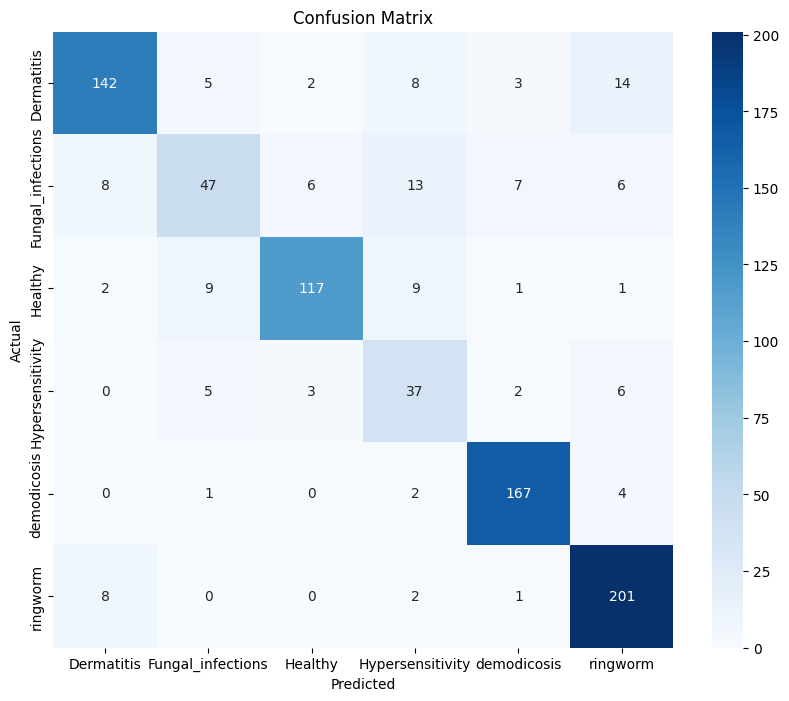

                   precision    recall  f1-score   support

       Dermatitis       0.89      0.82      0.85       174
Fungal_infections       0.70      0.54      0.61        87
          Healthy       0.91      0.84      0.88       139
 Hypersensitivity       0.52      0.70      0.60        53
      demodicosis       0.92      0.96      0.94       174
         ringworm       0.87      0.95      0.91       212

         accuracy                           0.85       839
        macro avg       0.80      0.80      0.80       839
     weighted avg       0.85      0.85      0.85       839



In [20]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = best_model.predict(images, verbose=0)
    predicted = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

Compare CNN vs EfficientNet-B0


In [21]:
import pandas as pd

comparison = pd.DataFrame({
    "Model":[
        "CNN",
        "EfficientNet-B0"
    ],
    "Validation Accuracy":[
        cnn_acc,
        eff_acc
    ],
    "Validation Loss":[
        cnn_loss,
        eff_loss
    ]
})

print(comparison)

             Model  Validation Accuracy  Validation Loss
0              CNN             0.338498         1.564158
1  EfficientNet-B0             0.814064         0.549931


Perform Error Analysis

In [22]:
import matplotlib.pyplot as plt

misclassified = []

for images, labels in val_ds:

    predictions = best_model.predict(images, verbose=0)
    predicted = np.argmax(predictions, axis=1)

    for i in range(len(labels)):
        if labels[i] != predicted[i]:
            misclassified.append((
                images[i],
                labels[i].numpy(),
                predicted[i]
            ))

print("Total Misclassified Images:", len(misclassified))

Total Misclassified Images: 128


display first 9 error

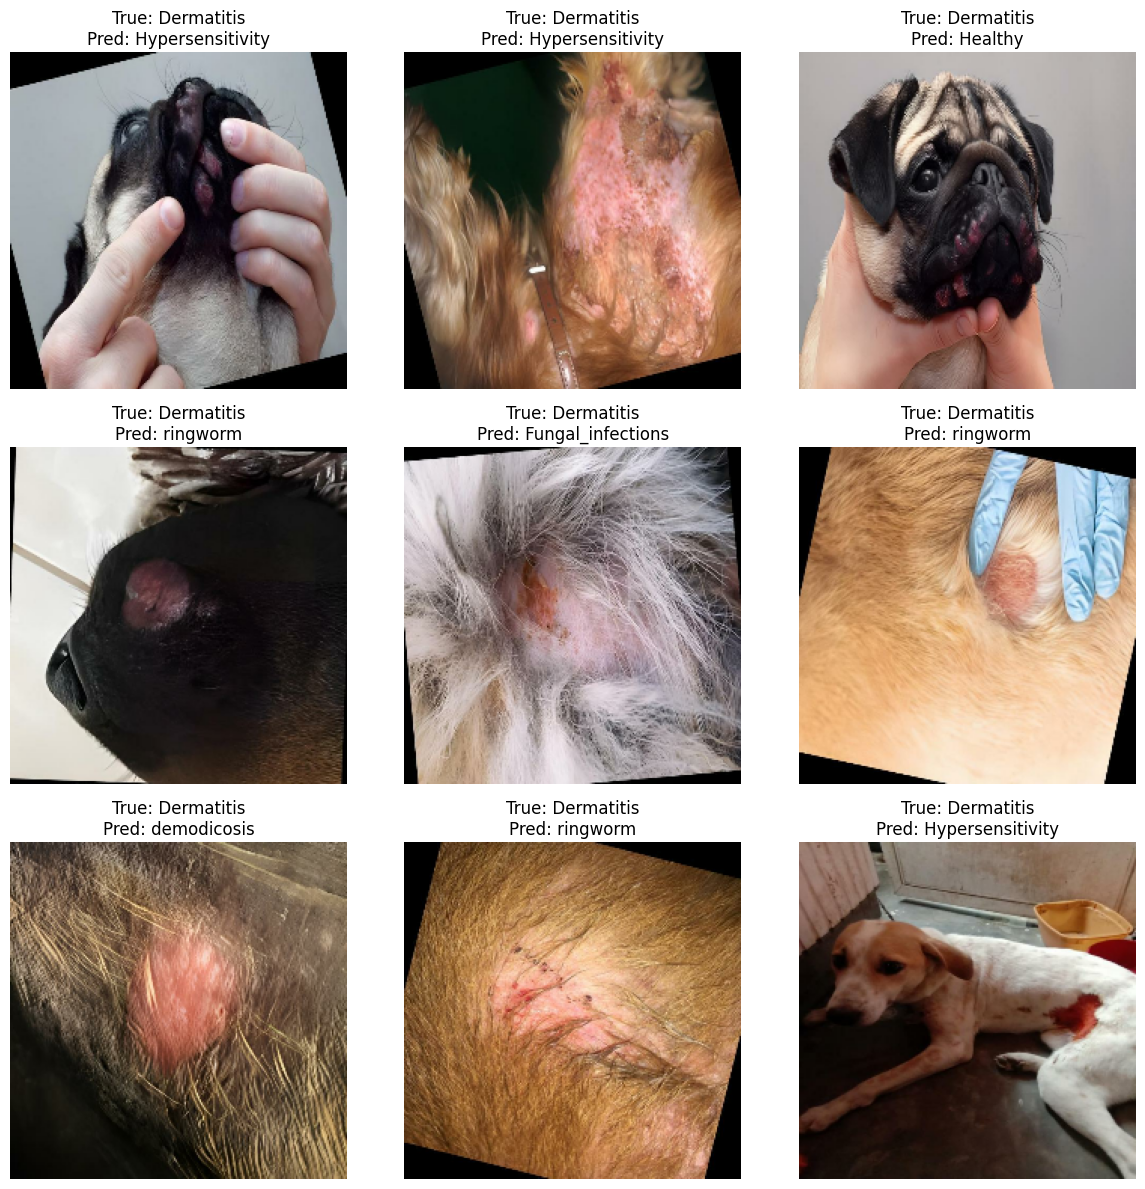

In [23]:
plt.figure(figsize=(12,12))

for i in range(min(9, len(misclassified))):

    image, true_label, pred_label = misclassified[i]

    plt.subplot(3,3,i+1)
    plt.imshow(image.numpy().astype("uint8"))
    plt.title(
        f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

Test Tuned Best Model

In [25]:
best_model = keras.models.load_model("best_model.keras")

In [28]:
from tensorflow.keras.preprocessing import image
import os

# Construct the path to the test directory
test_dir = '/content/drive/MyDrive/Dog_Skin_Disease_Final_Dataset/test'

# Get the list of class subdirectories in the test set
class_folders = os.listdir(test_dir)

if class_folders:
    # Take the first class folder
    first_class_folder = os.path.join(test_dir, class_folders[0])
    # Get the list of images in that class folder
    images_in_class = os.listdir(first_class_folder)

    if images_in_class:
        # Construct the full path to the first image found
        img_path = os.path.join(first_class_folder, images_in_class[0])
        print(f"Using image from test dataset: {img_path}")
    else:
        raise FileNotFoundError("No images found in the first class folder of the test dataset.")
else:
    raise FileNotFoundError("No class folders found in the test dataset directory.")


img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = best_model.predict(img_array)

predicted = np.argmax(prediction)

print("Predicted Class :", class_names[predicted])
print("Confidence :", np.max(prediction)*100,"%")

Using image from test dataset: /content/drive/MyDrive/Dog_Skin_Disease_Final_Dataset/test/Dermatitis/May-is-allergy-awareness-month-here-at-The-Shot-Spot_00064_jpg.rf.5fab1ae96cc6b5a907a967709d336eeb.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class : Dermatitis
Confidence : 96.254036 %


installing gradio

In [29]:
!pip install -q gradio

Save your trained model

In [30]:
best_model.save("final_deployment_model.keras")

Create the Gradio interface

In [35]:
import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image
import pandas as pd

# Load model
model = tf.keras.models.load_model("final_deployment_model.keras")

# Class names
class_names = train_ds.class_names

IMG_SIZE = (224,224)

def predict(image):

    image = image.resize(IMG_SIZE)

    img = np.array(image)/255.0
    img = np.expand_dims(img,0)

    predictions = model.predict(img, verbose=0)[0]

    pred_index = np.argmax(predictions)

    disease = class_names[pred_index]
    confidence = predictions[pred_index]*100

    # Top 3 predictions
    top3 = np.argsort(predictions)[::-1][:3]

    result = pd.DataFrame({
        "Disease":[class_names[i] for i in top3],
        "Confidence (%)":[round(predictions[i]*100,2) for i in top3]
    })

    return disease, f"{confidence:.2f}%", result, {
        class_names[i]: float(predictions[i]) for i in range(len(class_names))
    }

with gr.Blocks(theme=gr.themes.Soft(), title="Dog Disease Detection") as demo:

    gr.Markdown(
        """
        # DOg disease Detection using EfficientNet-B0

        Upload a Dog image and the model will predict the disease.
        """
    )

    with gr.Row():

        with gr.Column(scale=1):

            input_image = gr.Image(
                type="pil",
                label="Upload dog Image"
            )

            predict_btn = gr.Button(
                "🔍 Predict",
                variant="primary"
            )

            clear_btn = gr.ClearButton()

        with gr.Column(scale=1):

            disease = gr.Textbox(
                label="Predicted Disease"
            )

            confidence = gr.Textbox(
                label="Confidence"
            )

            label = gr.Label(
                label="Prediction Probabilities"
            )

    gr.Markdown("## Top 3 Predictions")

    table = gr.Dataframe(
        headers=["Disease","Confidence (%)"],
        interactive=False
    )

    predict_btn.click(
        fn=predict,
        inputs=input_image,
        outputs=[
            disease,
            confidence,
            table,
            label
        ]
    )

demo.launch(share=True)

/tmp/ipykernel_615/3197380095.py:41: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="Dog Disease Detection") as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://756a60e2bf09c56973.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
